In [1]:
import pandas as pd
import numpy as np
from dateutil import parser
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

Automobile Price Analysis in the Nigerian Used Car Market

The goal of this class work is to analyze a dataset of automobile listings to uncover insights into pricing trends, brand value, and factors influencing car prices in the Nigerian used car market.
The dataset contains details such as title, make, model, year, condition, transmission, and price.
1. Data Cleaning Phase
Objectives:
    Before any analysis, the dataset must be cleaned to ensure reliability.
Steps & Questions:
    Handle missing values
    How many missing values exist in each column (make, model, year)?
    Are there rows missing essential info like both make and model (likely unusable)?
    Clean the price column
    Convert the price from strings like “₦ 25,500,000” to float (25500000.00).
    Are there any outliers or invalid prices (too low/high)?

Standardize categorical columns
    Ensure consistent casing for make, model, condition, and transmission. e.g., “foreign used” to “Foreign Used”.
    Fix inconsistencies in naming (“Mercedes-Benz”, “Mercedes Benz”, etc.).
    Convert year to integer
    Check for missing value on year.
    Remove rows where the year is clearly invalid (e.g., > 2025 or < 1980).

2. Exploratory Data Analysis (EDA)
    Key Questions:
    What are the most common car brands (make)?
    Frequency count of each brand.
    Visualize with a bar chart.
    What are the most common models per brand?
    For example, which Toyota models appear most frequently?
    What’s the distribution of car years?
    Histogram of year shows age distribution of listed cars.
    What is the average price by brand and model?
    Compare mean/median price by make and model.
    Which brands are the most expensive on average?
    How does car condition affect price?
    Compare “Foreign Used” vs “Local Used” prices.
    Boxplot for visual insight.
    How does transmission type affect price?
    Compare “Automatic” vs “Manual”.
    Are automatic cars generally pricier?
    Are newer cars significantly more expensive?
    Scatterplot of year vs price.
    Correlation coefficient between year and price.

3. Visualization Plan
    Create the following visualizations (using Streamlit):
    KPI SECTION (Top of Dashboard)
    Q1. How many cars are listed in the dataset?
     Display the total number of car listings as a KPI.
    Q2. What is the average price of used cars in Nigeria?
    Display the mean car price (₦) as a KPI.
    Q3. Which car brand appears most frequently in the listings?
     Display the most common car make as a KPI.
    Q4. What percentage of cars are Foreign Used?
     Display the percentage of Foreign Used cars as a KPI.

Visualization
Description
Bar Chart
Count of cars by make
Bar Chart
Average price by make
Boxplot
Price distribution by condition
Histogram
Distribution of year
Scatter Plot
year vs price (colored by condition)
Heatmap
Correlation between numeric fields (e.g., year, price)


4. Summary of Findings
    Which brands dominate the higher price range, do Lexus, Mercedes-Benz, and Toyota consistently appear among the top?
    Do Foreign Used cars generally cost more than Local Used ones?
    How strongly does year correlate with price, does price clearly drop for older vehicles?
    Are automatic cars listed more frequently and at higher prices than manual ones?

Which models retain value better, for instance, how do Toyota Hilux and Lexus RX 350 compare with Honda Accord?

Business Insights & Recommendations
Write a concise 5–7 line summary based on your analysis. Your report should answer:
Which product (make/model) performs best overall?
Which sales channel (e.g., Foreign Used vs Local Used) contributes the most revenue?
Which period (e.g., year) records the highest released cars?
Suggest strategies to improve underperforming regions or channels. 
Include this summary at the end of your notebook as your final insight section.


In [2]:
#Loading the csv file
df = pd.read_csv("data/jiji_car_dataset.csv")

df.head()

,title,make,model,year,condition,transmission,price
0,Toyota Camry 2007 Gray,Toyota,Camry,2007.0,local used,automatic,"₦ 6,960,937"
1,Lexus ES 2014 Black,Lexus,ES,2014.0,local used,automatic,"₦ 13,500,000"
2,Mercedes-Benz M Class ML350 4MATIC 4dr SUV AWD...,Mercedes-Benz,M Class,2014.0,foreign used,automatic,"₦ 17,300,000"
3,Hyundai Santa Fe 2013 Blue,Hyundai,Santa Fe,2013.0,local used,automatic,"₦ 10,000,000"
4,Toyota Corolla Sedan Automatic 2003 Black,Toyota,Corolla Sedan,2003.0,local used,automatic,"₦ 3,800,000"


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         2000 non-null   str    
 1   make          1990 non-null   str    
 2   model         1990 non-null   str    
 3   year          1990 non-null   float64
 4   condition     2000 non-null   str    
 5   transmission  1998 non-null   str    
 6   price         2000 non-null   str    
dtypes: float64(1), str(6)
memory usage: 272.9 KB


In [4]:
df.columns = df.columns.str.title()
df.columns

Index(['Title', 'Make', 'Model', 'Year', 'Condition', 'Transmission', 'Price'], dtype='str')

In [5]:
df['Make'].value_counts()

Make
Toyota           887
Lexus            305
Mercedes-Benz    297
Honda            128
Hyundai           89
Acura             76
New               41
Ford              38
Nissan            21
Land              14
BMW               13
Kia               12
Mini              10
Pontiac            8
Jeep               8
Mazda              7
Dodge              6
Peugeot            5
Mitsubishi         4
Volkswagen         4
Volvo              3
Infiniti           3
Tesla              2
Audi               2
Cadillac           1
Lincoln            1
RAM                1
Changan            1
Citroen            1
BYD                1
Rolls-Royce        1
Name: count, dtype: int64

In [6]:
df.isnull().sum()

Title            0
Make            10
Model           10
Year            10
Condition        0
Transmission     2
Price            0
dtype: int64

In [7]:
#Clean price

df['Price'] = (
    df['Price']
    .astype(str)
    .replace(r"[₦,]", "", regex=True)
    .astype(float)
)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         2000 non-null   str    
 1   Make          1990 non-null   str    
 2   Model         1990 non-null   str    
 3   Year          1990 non-null   float64
 4   Condition     2000 non-null   str    
 5   Transmission  1998 non-null   str    
 6   Price         2000 non-null   float64
dtypes: float64(2), str(5)
memory usage: 245.7 KB


In [8]:
#Dropping all nan

df.dropna(inplace=True)

df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
Index: 1988 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         1988 non-null   str    
 1   Make          1988 non-null   str    
 2   Model         1988 non-null   str    
 3   Year          1988 non-null   float64
 4   Condition     1988 non-null   str    
 5   Transmission  1988 non-null   str    
 6   Price         1988 non-null   float64
dtypes: float64(2), str(5)
memory usage: 259.9 KB


Title           0
Make            0
Model           0
Year            0
Condition       0
Transmission    0
Price           0
dtype: int64

In [9]:
df[df['Title'].str.contains('New', case=False)]

,Title,Make,Model,Year,Condition,Transmission,Price
47,New Toyota Urban Cruiser 2025 Black,New,Toyota Urban,2025.0,brand new,automatic,5.800000e+07
65,New Honda CR-V 2023 Black,New,Honda CR-V,2023.0,brand new,automatic,7.500000e+07
76,New Toyota Land Cruiser 3.5 Petrol 4WD 2022 White,New,Toyota Land,2022.0,brand new,manual,1.250000e+08
132,New Toyota Hilux 2022 Gray,New,Toyota Hilux,2022.0,brand new,automatic,9.500000e+07
179,New Toyota Hilux 2023 Black,New,Toyota Hilux,2023.0,brand new,automatic,1.250000e+08
305,New Toyota Land Cruiser 2024 Black,New,Toyota Land,2024.0,brand new,automatic,2.100000e+08
360,New XPeng P7 424hp All Wheel 2025 Green,New,XPeng P7,2025.0,brand new,automatic,2.200000e+08
371,New Toyota Hilux 2022 Black,New,Toyota Hilux,2022.0,brand new,automatic,9.860000e+07
387,New Toyota Hilux 2022 White,New,Toyota Hilux,2022.0,brand new,automatic,9.800000e+07
454,New BYD Sealion 06 EV 2026 Blue,New,BYD Sealion,2026.0,brand new,automatic,7.000000e+07


In [10]:
#Dropping rows with wrong brand extraction
df = df[df['Make'] != 'New']

df.head()

,Title,Make,Model,Year,Condition,Transmission,Price
0,Toyota Camry 2007 Gray,Toyota,Camry,2007.0,local used,automatic,6960937.0
1,Lexus ES 2014 Black,Lexus,ES,2014.0,local used,automatic,13500000.0
2,Mercedes-Benz M Class ML350 4MATIC 4dr SUV AWD...,Mercedes-Benz,M Class,2014.0,foreign used,automatic,17300000.0
3,Hyundai Santa Fe 2013 Blue,Hyundai,Santa Fe,2013.0,local used,automatic,10000000.0
4,Toyota Corolla Sedan Automatic 2003 Black,Toyota,Corolla Sedan,2003.0,local used,automatic,3800000.0


In [11]:
#Dealing with Outliers

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

#Finding the Lower and upper bounds
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

outliers = (df['Price'] < lower_bound) | (df['Price'] > upper_bound)

print('Outliers:', outliers.sum())

Outliers: 152


In [12]:
#Excluding Outliers from dataframe using ""

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

new_df = df[
    (df['Price'] > lower_bound) & (df['Price'] < upper_bound)
]

new_df.info()
new_df['Make'].value_counts()

<class 'pandas.DataFrame'>
Index: 1795 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         1795 non-null   str    
 1   Make          1795 non-null   str    
 2   Model         1795 non-null   str    
 3   Year          1795 non-null   float64
 4   Condition     1795 non-null   str    
 5   Transmission  1795 non-null   str    
 6   Price         1795 non-null   float64
dtypes: float64(2), str(5)
memory usage: 234.1 KB


Make
Toyota           843
Lexus            264
Mercedes-Benz    245
Honda            125
Hyundai           86
Acura             74
Ford              37
Nissan            21
Land              13
Kia               12
BMW               11
Mini               9
Pontiac            8
Jeep               8
Mazda              7
Dodge              6
Peugeot            5
Mitsubishi         4
Volkswagen         4
Volvo              3
Infiniti           3
Tesla              2
Audi               1
RAM                1
Changan            1
Citroen            1
BYD                1
Name: count, dtype: int64

In [13]:
#Standardize categorical columns

category = ['Model', 'Condition', 'Transmission']

for cat in category:
    new_df[cat] = new_df[cat].astype(str).str.title()

new_df

,Title,Make,Model,Year,Condition,Transmission,Price
0,Toyota Camry 2007 Gray,Toyota,Camry,2007.0,Local Used,Automatic,6960937.0
1,Lexus ES 2014 Black,Lexus,Es,2014.0,Local Used,Automatic,13500000.0
2,Mercedes-Benz M Class ML350 4MATIC 4dr SUV AWD...,Mercedes-Benz,M Class,2014.0,Foreign Used,Automatic,17300000.0
3,Hyundai Santa Fe 2013 Blue,Hyundai,Santa Fe,2013.0,Local Used,Automatic,10000000.0
4,Toyota Corolla Sedan Automatic 2003 Black,Toyota,Corolla Sedan,2003.0,Local Used,Automatic,3800000.0
...,...,...,...,...,...,...,...
1995,Volkswagen Golf TSI SEL 4-Door FWD 2017 Gray,Volkswagen,Golf Tsi,2017.0,Foreign Used,Automatic,19500000.0
1996,Toyota Camry XSE FWD (2.5L 4cyl 8AM) 2018 White,Toyota,Camry Xse,2018.0,Foreign Used,Automatic,34000000.0
1997,Toyota Camry LE FWD (2.5L 4cyl 8AM) 2018 Brown,Toyota,Camry Le,2018.0,Foreign Used,Automatic,21000000.0
1998,Toyota Camry LE 4dr Sedan (2.5L 4cyl 6A) 2012 ...,Toyota,Camry Le,2012.0,Foreign Used,Automatic,12700000.0


In [14]:
#Changing year to integar
new_df['Year'] = df['Year'].astype(int)

new_df.isnull().sum()
new_df.info()

<class 'pandas.DataFrame'>
Index: 1795 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         1795 non-null   str    
 1   Make          1795 non-null   str    
 2   Model         1795 non-null   str    
 3   Year          1795 non-null   int64  
 4   Condition     1795 non-null   str    
 5   Transmission  1795 non-null   str    
 6   Price         1795 non-null   float64
dtypes: float64(1), int64(1), str(5)
memory usage: 234.1 KB


In [15]:
new_df.loc[new_df['Year']<=2000]

,Title,Make,Model,Year,Condition,Transmission,Price
18,Nissan Pathfinder Automatic 2000 Gray,Nissan,Pathfinder Automatic,2000,Local Used,Automatic,3500000.0
152,Lexus RX 2000 Blue,Lexus,Rx,2000,Local Used,Automatic,3800000.0
274,Toyota Tundra 1794 5.7L V8 w/FFV 4x4 CrewMax 5...,Toyota,Tundra,1794,Foreign Used,Automatic,39000000.0
919,Volkswagen Golf 1999 Red,Volkswagen,Golf,1999,Foreign Used,Automatic,6000000.0


In [16]:
#Filtering for invalid years
dfi = new_df[(new_df['Year'] > 2025) | (new_df['Year'] < 1980)]
dfi['Year']

274     1794
1856    2026
Name: Year, dtype: int64

In [17]:

new_df = new_df[(new_df['Year'] < 2025) & (new_df['Year'] > 1990)]

new_df.head()


,Title,Make,Model,Year,Condition,Transmission,Price
0,Toyota Camry 2007 Gray,Toyota,Camry,2007,Local Used,Automatic,6960937.0
1,Lexus ES 2014 Black,Lexus,Es,2014,Local Used,Automatic,13500000.0
2,Mercedes-Benz M Class ML350 4MATIC 4dr SUV AWD...,Mercedes-Benz,M Class,2014,Foreign Used,Automatic,17300000.0
3,Hyundai Santa Fe 2013 Blue,Hyundai,Santa Fe,2013,Local Used,Automatic,10000000.0
4,Toyota Corolla Sedan Automatic 2003 Black,Toyota,Corolla Sedan,2003,Local Used,Automatic,3800000.0


In [18]:

new_df.to_csv('data/cleaned_jiji_autos.csv', index=False)
new_df.info()

<class 'pandas.DataFrame'>
Index: 1790 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         1790 non-null   str    
 1   Make          1790 non-null   str    
 2   Model         1790 non-null   str    
 3   Year          1790 non-null   int64  
 4   Condition     1790 non-null   str    
 5   Transmission  1790 non-null   str    
 6   Price         1790 non-null   float64
dtypes: float64(1), int64(1), str(5)
memory usage: 233.4 KB


In [46]:
#EDA

In [47]:
# # What are the most common car brands (make)?
# # Frequency count of each brand.
# Visualize with a bar chart.

new_df['Make'].value_counts().head()


Make
Toyota           840
Lexus            264
Mercedes-Benz    245
Honda            124
Hyundai           86
Name: count, dtype: int64

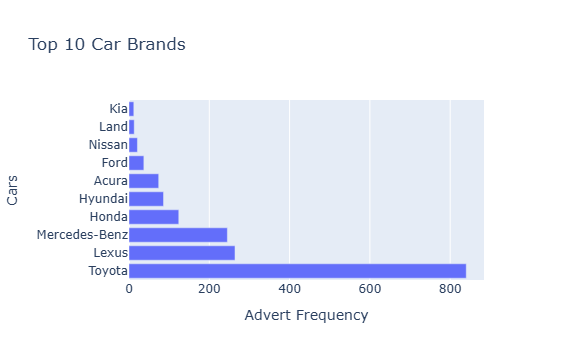

In [48]:
#Bar chart of common brands

brand = new_df.groupby('Make')['Make'].value_counts().sort_values(ascending=False).head(10)
fig1 = px.bar(
    x=brand.values,
    y=brand.index,
    title='Top 10 Car Brands'

)
fig1.update_layout(xaxis_title='Advert Frequency', yaxis_title='Cars')
fig1.show()

In [49]:
#Common Models By Brand

model_counts = new_df.groupby('Make')['Model'].value_counts().sort_values(ascending=False).head(20).reset_index(name='Count')
print(model_counts)


             Make               Model  Count
0          Toyota               Camry    106
1           Lexus              Rx 350     77
2          Toyota             Corolla     62
3          Toyota            Camry Se     44
4          Toyota            Camry Le     42
5           Honda              Accord     40
6   Mercedes-Benz             M Class     40
7           Lexus              Es 350     39
8          Toyota          Corolla Le     35
9          Toyota  Highlander Limited     31
10         Toyota                Rav4     30
11         Toyota           Camry Xle     30
12          Lexus                  Rx     26
13          Acura             Mdx Suv     26
14  Mercedes-Benz             Gla 250     23
15          Lexus              Rx 330     22
16          Lexus              Gx 460     21
17         Toyota      Highlander Xle     20
18         Toyota               Venza     20
19  Mercedes-Benz                E350     18


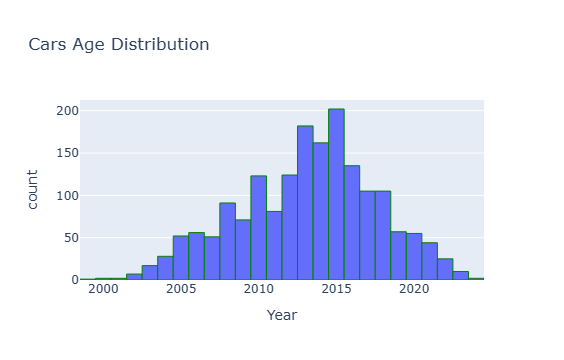

In [50]:
#Histogram of year shows age distribution of listed cars.

fig2 = px.histogram(
    new_df,
    x='Year',
    nbins=50,
    title='Cars Age Distribution'
)
fig2.update_traces(
    marker_line_color='green',
    marker_line_width=1
)
fig2.show()


In [51]:
# Compare mean/median price by make.
# Which brands are the most expensive on average?
round(new_df.groupby('Make')['Price'].mean(), 2).sort_values(ascending=False).head(15)


Make
Tesla            59000000.00
Jeep             47250000.00
Land             45038461.54
RAM              38000000.00
Changan          38000000.00
Citroen          37000000.00
Dodge            34833333.33
BMW              34418181.82
Mercedes-Benz    28667461.73
Infiniti         27500000.00
Audi             26500000.00
Lexus            24425473.48
Toyota           22326542.03
Volvo            19733333.33
Mini             19300000.00
Name: Price, dtype: float64

In [52]:
# Compare mean/median price by model.

round(new_df.groupby('Model')['Price'].mean(), 2).sort_values(ascending=False).head(15)


Model
4-Runner Sr5        68000000.00
Hilux 2             68000000.00
X3 Xdrive30I        65500000.00
Pilot Black         65000000.00
Palisade            65000000.00
Gls-Class Gls550    65000000.00
Lx 570              62833333.33
Gl-Class Gl63       62000000.00
X6                  60000000.00
Model 3             60000000.00
Fortuner            59000000.00
Highlander Xse      58000000.00
Model S             58000000.00
Rdx W               58000000.00
Wrangler Sport      58000000.00
Name: Price, dtype: float64

In [64]:
# Isolate Foreign Used and Local Used data
foreign_used = new_df[new_df['Condition'] == 'Foreign Used']
local_used = new_df[new_df['Condition'] == 'Local Used']

# Compare statistical summaries
print("Foreign Used Summary:")
print(round(foreign_used['Price'].describe(), 2))

print("\nLocal Used Summary:")
print(round(local_used['Price'].describe(), 2))

# round(local_used['Price'].describe(), 2)


Foreign Used Summary:
count        1522.00
mean     24091276.90
std      14091001.72
min       4000000.00
25%      13500000.00
50%      19500000.00
75%      29500000.00
max      68000000.00
Name: Price, dtype: float64

Local Used Summary:
count         268.00
mean     13849416.97
std      12052010.86
min       1960000.00
25%       6500000.00
50%      10000000.00
75%      16625000.00
max      67000000.00
Name: Price, dtype: float64


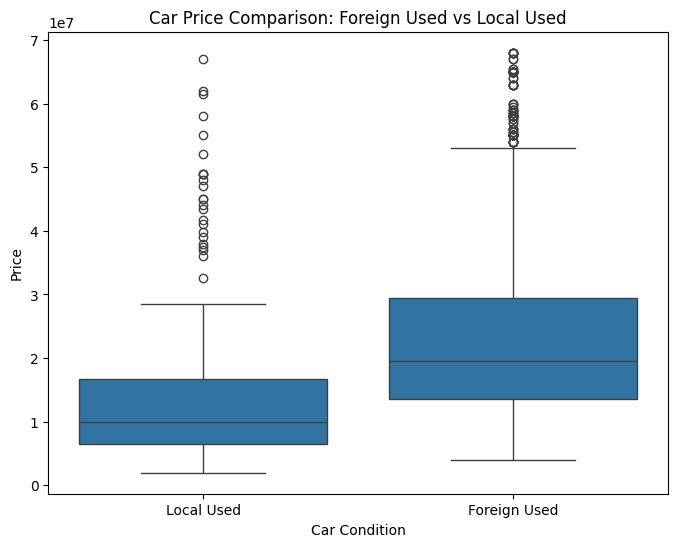

In [65]:
# How does car condition affect price?
# Compare “Foreign Used” vs “Local Used” prices.
# Boxplot for visual insight.

# 1. Filter dataset for only the two conditions
target_conditions = ["Foreign Used", "Local Used"]
filtered_df = new_df[new_df["Condition"].isin(target_conditions)]

# 2. Create the boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=filtered_df, x="Condition", y="Price")

# 3. Customize and display
plt.title("Car Price Comparison: Foreign Used vs Local Used")
plt.xlabel("Car Condition")
plt.ylabel("Price")
plt.show()


In [66]:
# How does transmission type affect price?
# Compare “Automatic” vs “Manual”.
# Are automatic cars generally pricier?


#Group Automatic and Manual transmission data
automatic_cars = new_df[new_df['Transmission'] == 'Automatic']
manual_cars = new_df[new_df['Transmission'] == 'Manual']

# Compare statistical summaries
print("Automatic Transmission Summary:")
print(round(automatic_cars['Price'].describe(), 2))

print("\nManual Transmission Summary:")
print(round(manual_cars['Price'].describe(), 2))

Automatic Transmission Summary:
count        1771.00
mean     22561359.22
std      14227162.22
min       1960000.00
25%      12500000.00
50%      18000000.00
75%      28000000.00
max      68000000.00
Name: Price, dtype: float64

Manual Transmission Summary:
count          19.00
mean     22231578.95
std      18882290.43
min       2800000.00
25%       8750000.00
50%      15000000.00
75%      31000000.00
max      55000000.00
Name: Price, dtype: float64


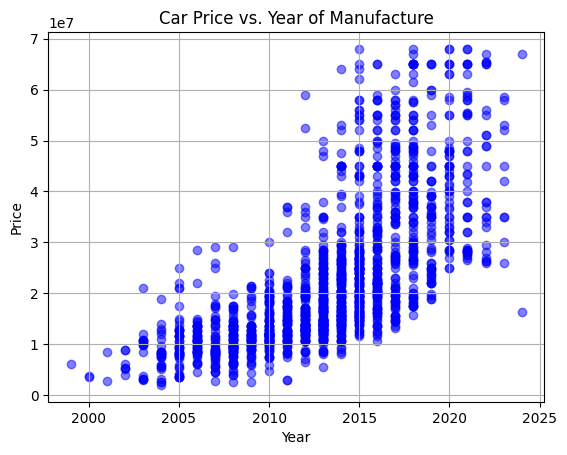

In [74]:
# Are newer cars significantly more expensive?
# Scatterplot of year vs price.


plt.scatter(new_df['Year'], new_df['Price'], alpha=0.5, color='blue')
plt.title('Car Price vs. Year of Manufacture')
plt.xlabel('Year')
plt.ylabel('Price')
plt.grid(linestyle='-', alpha=1)
plt.show()


In [69]:
# Correlation coefficient between year and price.

correlation = new_df['Year'].corr(new_df['Price'])

print(f"Correlation coefficient between Year and Price: {round(correlation, 4)}")


Correlation coefficient between Year and Price: 0.6948
